<a href="https://colab.research.google.com/github/Nisha-sah/Concepts-and-Technologies-of-AI/blob/main/WLVID_Pragya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regression

1.	Exploratory Data Analysis and Data Understanding
Dataset: Hotel Booking Demand Dataset
Source: Kaggle
Created by: Antonio, Almeida & Nunes (2019)

Access Method:
The dataset was downloaded from Kaggle and loaded into a Pandas DataFrame using pd.read_csv().

UNSDG Alignment:
This dataset aligns with UNSDG 8  Decent Work and Economic Growth, as hotel pricing (ADR) reflects tourism demand, economic activity, and sustainable revenue optimization in the hospitality sector.

Questions:

How does lead time affect hotel pricing (ADR)?

Do hotel type and seasonality influence room rates?

Does group size impact average daily rate?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

Load Dataset and Explore

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/hotel_bookings.csv")

print(df.shape)
print(df.info())


(119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  mea

Data Cleaning & Preprocessing

In [ ]:
df['children'] = df['children'].fillna(0)
df['babies'] = df['babies'].fillna(0)
df = df[df['adr'] > 0]
df = df[df['adults'] + df['children'] + df['babies'] > 0]

# Feature Engineering
df['total_guests'] = df['adults'] + df['children'] + df['babies']


FEATURE SELECTION (10 COLUMNS)

In [ ]:
features = [
    'hotel',
    'lead_time',
    'arrival_date_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'total_guests',
    'is_canceled',
    'arrival_date_year'
]

X = df[features]
y = df['adr']

In [ ]:
#Encode Categorical Columns
X = pd.get_dummies(X, drop_first=True)


In [ ]:
cat_cols = ['hotel', 'arrival_date_month']
for col in cat_cols:
    print(df[col].value_counts())

hotel
City Hotel      78092
Resort Hotel    39307
Name: count, dtype: int64
arrival_date_month
August       13707
July         12488
May          11608
April        10952
October      10929
June         10817
September    10349
March         9637
February      7919
November      6635
December      6558
January       5800
Name: count, dtype: int64


Box plotter

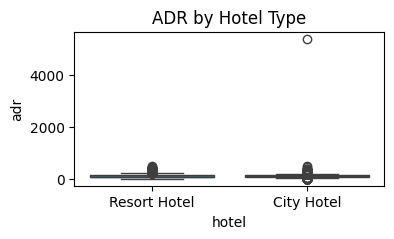

In [ ]:
plt.figure(figsize=(4,2))
sns.boxplot(x='hotel', y='adr', data=df)
plt.title("ADR by Hotel Type")
plt.show()

Histogram plotter

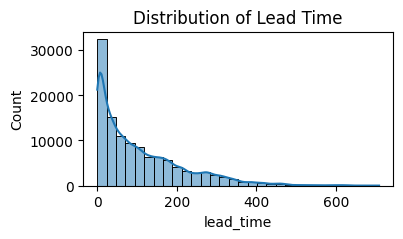

In [ ]:
# Lead Time Distribution
plt.figure(figsize=(4,2))
sns.histplot(df['lead_time'], bins=30, kde=True)
plt.title("Distribution of Lead Time")
plt.show()

Histogram plotter

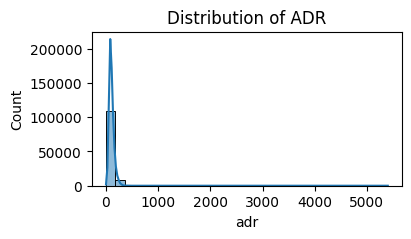

In [ ]:
# ADR Distribution
plt.figure(figsize=(4,2))
sns.histplot(df['adr'], bins=30, kde=True)
plt.title("Distribution of ADR")
plt.show()

Histogram plotter

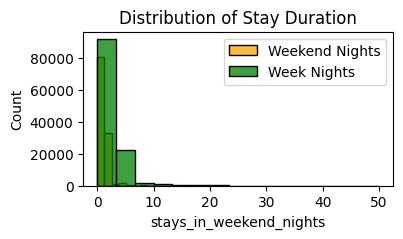

In [ ]:
# Stay Duration (Weekend vs Week Nights)
plt.figure(figsize=(4,2))
sns.histplot(df['stays_in_weekend_nights'], bins=15, kde=False, color='orange', label='Weekend Nights')
sns.histplot(df['stays_in_week_nights'], bins=15, kde=False, color='green', label='Week Nights')
plt.title("Distribution of Stay Duration")
plt.legend()
plt.show()

Histogram plotter

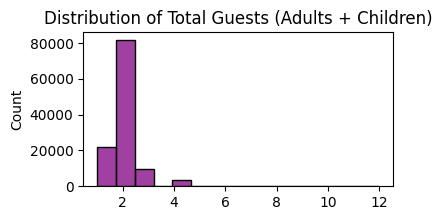

In [ ]:
# Adults + Children Distribution
plt.figure(figsize=(4,2))
sns.histplot(df['adults'] + df['children'], bins=15, kde=False, color='purple')
plt.title("Distribution of Total Guests (Adults + Children)")
plt.show()
# Total Guests Column
df['total_guests'] = df['adults'] + df['children'] + df['babies']


Bar Plotter

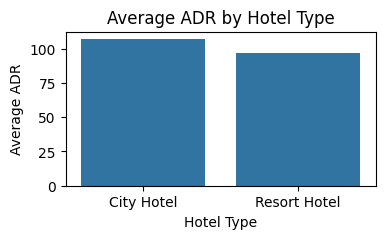

In [ ]:
# Average ADR by Hotel Type
plt.figure(figsize=(4,2))
avg_adr_hotel = df.groupby('hotel')['adr'].mean()
sns.barplot(x=avg_adr_hotel.index, y=avg_adr_hotel.values)
plt.xlabel("Hotel Type")
plt.ylabel("Average ADR")
plt.title("Average ADR by Hotel Type")
plt.show()

Barchart plotter

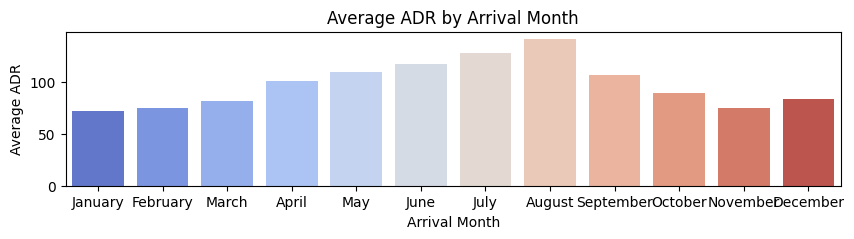

In [ ]:
plt.figure(figsize=(10, 2))

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

avg_adr_month = (
    df.groupby('arrival_date_month')['adr']
      .mean()
      .reindex(month_order)
)

sns.barplot(
    x=avg_adr_month.index,
    y=avg_adr_month.values,
    hue=avg_adr_month.index,
    palette="coolwarm",

)

plt.xlabel("Arrival Month")
plt.ylabel("Average ADR")
plt.title("Average ADR by Arrival Month")
plt.show()

Scatter plotter

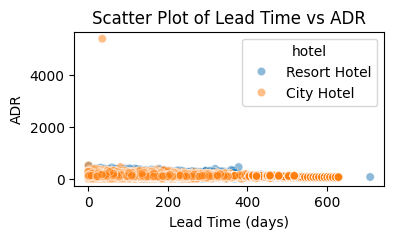

In [ ]:
# Scatter Plots: Lead Time vs ADR
plt.figure(figsize=(4,2))
sns.scatterplot(x='lead_time', y='adr', hue='hotel', data=df, alpha=0.5)
plt.xlabel("Lead Time (days)")
plt.ylabel("ADR")
plt.title("Scatter Plot of Lead Time vs ADR")
plt.show()

Scatter plotter

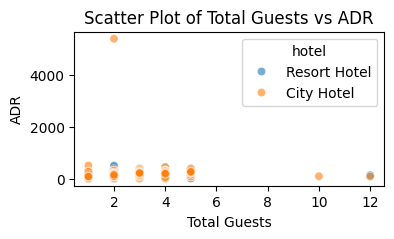

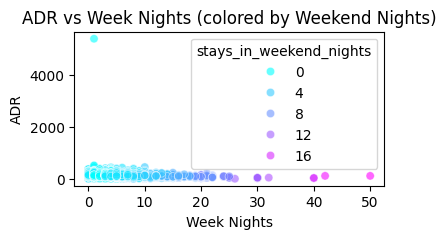

In [ ]:
# Total Guests vs ADR
plt.figure(figsize=(4,2))
sns.scatterplot(x='total_guests', y='adr', hue='hotel', data=df, alpha=0.6)
plt.xlabel("Total Guests")
plt.ylabel("ADR")
plt.title("Scatter Plot of Total Guests vs ADR")
plt.show()


# Week vs Weekend Nights vs ADR
plt.figure(figsize=(4,2))
sns.scatterplot(x='stays_in_week_nights', y='adr', hue='stays_in_weekend_nights', data=df, palette='cool', alpha=0.6)
plt.xlabel("Week Nights")
plt.ylabel("ADR")
plt.title("ADR vs Week Nights (colored by Weekend Nights)")
plt.show()

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Build Two Classical Regression Models
Model 1: Linear Regression

In [ ]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

Random forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

Model Evaluation (MANDATORY METRICS)

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, rf_pred, "Random Forest Regressor")



Linear Regression
MAE: 25.212045803276975
MSE: 1130.7145315731875
RMSE: 33.62609896454222
R2 Score: 0.4786374720635045

Random Forest Regressor
MAE: 14.44287584337228
MSE: 716.1017958636485
RMSE: 26.760078397935395
R2 Score: 0.669811758736409


Comparison Table

In [ ]:
# 6. Model comparison table
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

print("\nModel Comparison:")
print(comparison_df)


Model Comparison:
               Model        MAE       RMSE  R2 Score
0  Linear Regression  25.212046  33.626099  0.478637
1      Random Forest  14.442876  26.760078  0.669812


Neural Network Regression Model

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define MLP Regressor model
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Train the model
mlp.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# Evaluation metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Display results
print("Neural Network (MLP Regressor) Performance\n")

print("Training Performance:")
print(f"MSE: {train_mse:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R² Score: {train_r2:.3f}")

print("\nTest Performance:")
print(f"MSE: {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R² Score: {test_r2:.3f}")

Neural Network (MLP Regressor) Performance

Training Performance:
MSE: 910.91
RMSE: 30.18
R² Score: 0.633

Test Performance:
MSE: 642.01
RMSE: 25.34
R² Score: 0.704


4.	Hyperparameter Optimization with Cross-Validation
Apply Cross-Validation (GridSearchCV)
Linear Regression  Grid Search

In [ ]:
lr = LinearRegression()

lr_param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr_grid = GridSearchCV(
    lr,
    lr_param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

lr_grid.fit(X_train_scaled, y_train)

print("Best Linear Regression Parameters:", lr_grid.best_params_)
print("Best CV RMSE (Linear Regression):",
      np.sqrt(-lr_grid.best_score_))

Best Linear Regression Parameters: {'fit_intercept': True, 'positive': False}
Best CV RMSE (Linear Regression): 37.897040588900936


Random Forest  Grid Search

In [25]:
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("\nBest Random Forest Parameters:", rf_grid.best_params_)
print("Best CV RMSE (Random Forest):",
        np.sqrt(-rf_grid.best_score_))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV RMSE (Random Forest): 29.773178146408785


summary table

In [26]:
cv_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Best Parameters": [
        lr_grid.best_params_,
        rf_grid.best_params_
    ],
    "Best CV RMSE": [
        np.sqrt(-lr_grid.best_score_),
        np.sqrt(-rf_grid.best_score_)
    ]
})

print("\nCross-Validation Summary:")
print(cv_summary)


Cross-Validation Summary:
               Model                                    Best Parameters  \
0  Linear Regression         {'fit_intercept': True, 'positive': False}   
1      Random Forest  {'max_depth': None, 'min_samples_leaf': 2, 'mi...   

   Best CV RMSE  
0     37.897041  
1     29.773178  


Feature Selection (Correlation-based)

In [27]:
# 1. Correlation with target
corr = df.corr(numeric_only=True)['adr'].abs().sort_values(ascending=False)

# 2. Select top features per model
lr_features = corr.drop('adr').head(10).index  # Top 10 for Linear Regression
rf_features = corr.drop('adr').head(8).index   # Top 8 for Random Forest

# 3. Prepare datasets
X_lr = df[lr_features]
X_rf = df[rf_features]
y = df['adr']

Final Models with Selected Features
Rebuild models with:
Split the features per model:

Train/test split separately for each model:

In [28]:
# 4. Train-test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y, test_size=0.2, random_state=42
)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y, test_size=0.2, random_state=42
)

Scale only Linear Regression features:

In [29]:
# Scaling for Linear Regression
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

#  Fit models
lr_final = LinearRegression(**lr_grid.best_params_)
lr_final.fit(X_train_lr_scaled, y_train_lr)
lr_pred = lr_final.predict(X_test_lr_scaled)

Random Forest (NO scaling)

In [30]:
rf_final = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
rf_final.fit(X_train_rf, y_train_rf)
rf_pred = rf_final.predict(X_test_rf)

Final Comparison Table:

In [31]:
# 7. Evaluation function (including MAE)
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

lr_rmse, lr_mae, lr_r2 = evaluate_model(y_test_lr, lr_pred)
rf_rmse, rf_mae, rf_r2 = evaluate_model(y_test_rf, rf_pred)

# 8. Summary table
final_comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Features Used": [len(lr_features), len(rf_features)],
    "CV RMSE": [
        np.sqrt(-lr_grid.best_score_),
        np.sqrt(-rf_grid.best_score_)
    ],
    "Test RMSE": [lr_rmse, rf_rmse],
    "Test MAE": [lr_mae, rf_mae],
    "Test R²": [lr_r2, rf_r2]
})

print(final_comparison_df)

               Model  Features Used    CV RMSE  Test RMSE   Test MAE   Test R²
0  Linear Regression             10  37.897041  38.875368  29.190560  0.303156
1      Random Forest              8  29.773178  28.869064  18.443852  0.615716
